# Exploration de la base prospects EdTech TUT'TOP

**Pipeline agent de prospection intelligent**  
Base nettoyée, dédupliquée, scorée et qualifiée (Chaud / Tiède / Froid)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.rcParams.update({'font.size': 12, 'figure.figsize': (14, 6)})
sns.set_style('whitegrid')
print('OK')

OK


## 1. Chargement des données

In [35]:
# Avant nettoyage (brut + score, sans dedup)
bc = pd.read_csv('data/all_data_before_clean.csv', dtype=str, encoding='utf-8-sig').fillna('')
# Apres nettoyage (dedupe + score)
df = pd.read_csv('data/all_data_enriched.csv', dtype=str, encoding='utf-8-sig').fillna('')

print(f'Avant clean : {len(bc):>8,} lignes')
print(f'Apres clean  : {len(df):>8,} lignes')
print(f'Supprimes    : {len(bc)-len(df):>8,} ({(len(bc)-len(df))/len(bc)*100:.1f}%)')

Avant clean :  121,011 lignes
Apres clean  :  120,523 lignes
Supprimes    :      488 (0.4%)


In [36]:
df.head(20)

,nom,type,localisation,site_web,email,telephone,source,pays,score,qualification
0,Collège Jean Rous,Public,"Pia, Pyrénées-Orientales",https://jean-rous.mon-ent-occitanie.fr,ce.0660866h@ac-montpellier.fr,04 68 80 18 70,api_api_france,France,75,Chaud
1,Collège Saint-Philippe Néri,Privé,"Antibes, Alpes-Maritimes",http://www.saint-philippe-neri.fr,ce.0060823m@ac-nice.fr,04 97 21 70 50,api_api_france,France,78,Chaud
2,LP René Cassin,Public,"Paris, Paris",http://lyc-rene-cassin.ac-paris.fr,ce.0750588g@ac-paris.fr,01 42 88 33 66,api_api_france,France,58,Chaud
3,Collège Jean Moulin,Public,"Coulounieix-Chamiers, Dordogne",https://webetab.ac-bordeaux.fr/college-jean-mo...,ce.0240047w@ac-bordeaux.fr,05 53 02 08 20,api_api_france,France,70,Chaud
4,Lycée Frédéric Mistral,Public,"Nîmes, Gard",https://frederic-mistral-nimes.mon-ent-occitan...,ce.0300058a@ac-montpellier.fr,04 66 04 72 72,api_api_france,France,75,Chaud
5,Lycée polyvalent Irène et Frédéric Joliot-Curie,Public,"Sète, Hérault",https://joliot-curie.mon-ent-occitanie.fr,ce.0340076y@ac-montpellier.fr,04 67 18 66 66,api_api_france,France,75,Chaud
6,Lycée professionnel agricole Honoré de Balzac,Public,"Castelnau-le-Lez, Hérault",http://www.hdebalzac.fr,lpa.castelnau-le-lez@educagri.fr,04 99 58 36 58,api_api_france,France,65,Chaud
7,Collège privé Saint-Joseph,Privé,"Secondigny, Deux-Sèvres",http://stjo-secondigny.fr,ce.0790074b@ac-poitiers.fr,05 49 63 71 02,api_api_france,France,78,Chaud
8,Lycée polyvalent Denis Diderot,Public,"Marseille, Bouches-du-Rhône",http://www.lyc-diderot.ac-aix-marseille.fr,ce.0130050j@ac-aix-marseille.fr,04 91 10 07 00,api_api_france,France,68,Chaud
9,Lycée Marc Bloch,Public,"Val-de-Reuil, Eure",https://marc-bloch.lycee.ac-normandie.fr,ce.0271582y@ac-normandie.fr,02 32 59 50 75,api_api_france,France,70,Chaud


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120523 entries, 0 to 120522
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   nom            120523 non-null  object
 1   type           120523 non-null  object
 2   localisation   120523 non-null  object
 3   site_web       120523 non-null  object
 4   email          120523 non-null  object
 5   telephone      120523 non-null  object
 6   source         120523 non-null  object
 7   pays           120523 non-null  object
 8   score          120523 non-null  object
 9   qualification  120523 non-null  object
dtypes: object(10)
memory usage: 9.2+ MB


## 2. Valeurs manquantes

In [37]:
missing = pd.DataFrame({
    'colonne': df.columns,
    'vides': [(df[c]=='').sum() for c in df.columns],
    'total': len(df)
})
missing['pct'] = (missing['vides'] / missing['total'] * 100).round(1)
missing = missing[missing['vides'] > 0].sort_values('vides', ascending=False)
missing

,colonne,vides,total,pct
4,email,69682,120523,57.8
5,telephone,61792,120523,51.3
3,site_web,57114,120523,47.4


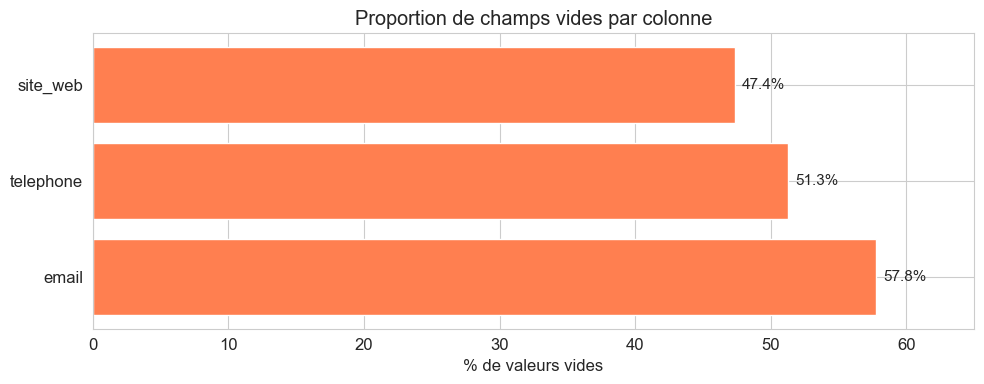

In [38]:
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(missing['colonne'], missing['pct'], color='coral', edgecolor='white')
for b, p in zip(bars, missing['pct']):
    ax.text(b.get_width()+0.5, b.get_y()+b.get_height()/2, f'{p}%', va='center', fontsize=11)
ax.set_xlabel('% de valeurs vides')
ax.set_title('Proportion de champs vides par colonne')
ax.set_xlim(0, 65)
plt.tight_layout()
plt.show()

## 3. Distribution par type d'établissement

In [39]:
type_counts = df['type'].value_counts()
type_counts

type
Public     99596
Privé      13429
Inconnu     7498
Name: count, dtype: int64

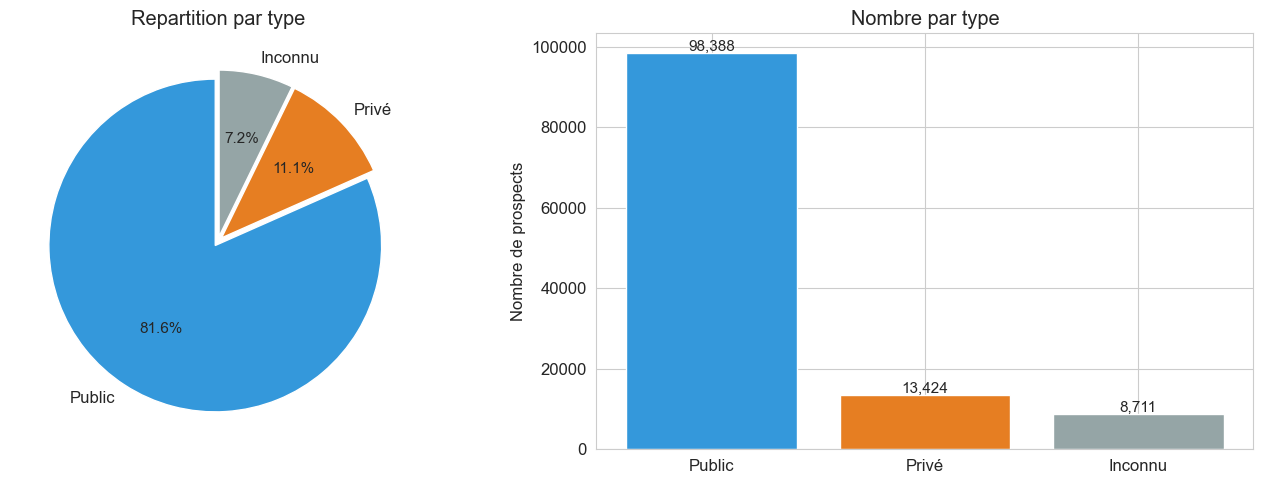

In [11]:
colors = {'Public': '#3498db', 'Privé': '#e67e22', 'Inconnu': '#95a5a6'}
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

wedges, texts, autotexts = ax1.pie(
    type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
    colors=[colors.get(t, '#999') for t in type_counts.index],
    startangle=90, explode=[0.03]*len(type_counts)
)
for at in autotexts:
    at.set_fontsize(11)
ax1.set_title('Repartition par type')

bars = ax2.bar(type_counts.index, type_counts.values, color=[colors.get(t, '#999') for t in type_counts.index], edgecolor='white')
for b in bars:
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+500, f"{int(b.get_height()):,}", ha='center', fontsize=11)
ax2.set_ylabel('Nombre de prospects')
ax2.set_title('Nombre par type')
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 4. Distribution géographique (Top 15)

In [12]:
pays_counts = df['pays'].value_counts().head(15)
pays_counts

pays
France         44426
Royaume-Uni    33102
Italie          7499
Suede           7161
Portugal        6376
Norvege         4427
Roumanie        3250
Hongrie         3154
Croatie         1837
Danemark        1698
Tchequie        1204
Tunisie         1185
Lituanie        1163
Pologne          905
Finlande         701
Name: count, dtype: int64

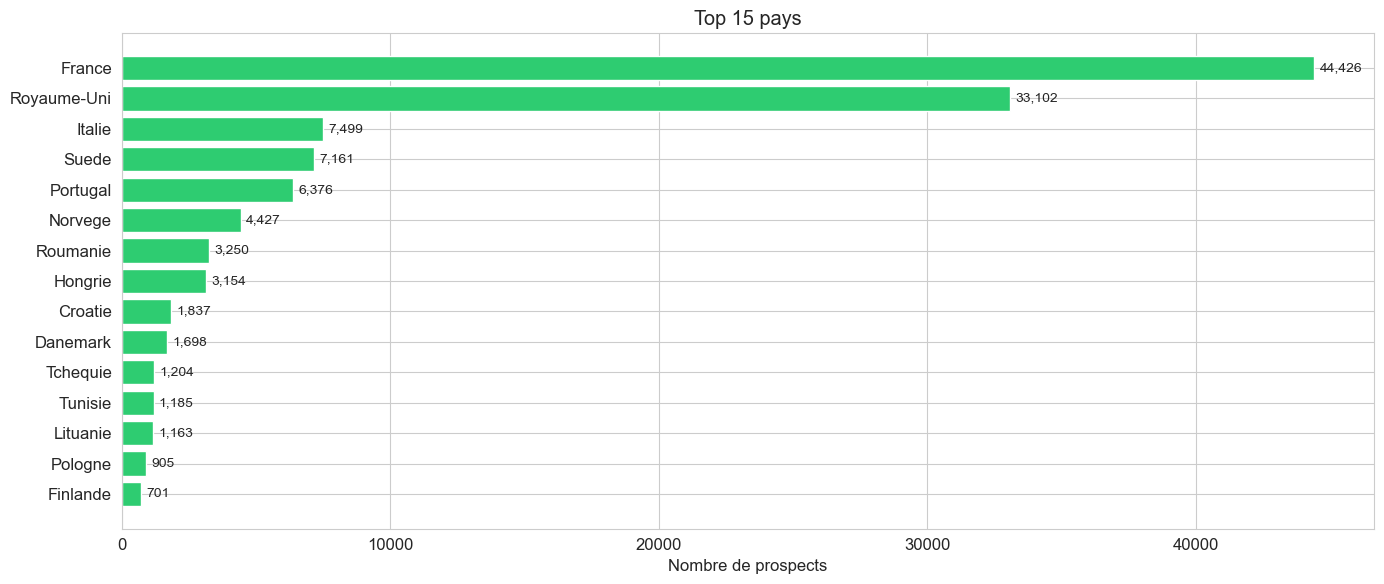

In [13]:
fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(range(len(pays_counts)), pays_counts.values, color='#2ecc71', edgecolor='white')
ax.set_yticks(range(len(pays_counts)))
ax.set_yticklabels(pays_counts.index)
ax.invert_yaxis()
for b, v in zip(bars, pays_counts.values):
    ax.text(b.get_width()+200, b.get_y()+b.get_height()/2, f'{v:,}', va='center', fontsize=10)
ax.set_xlabel('Nombre de prospects')
ax.set_title('Top 15 pays')
plt.tight_layout()
plt.show()

## 5. Score et Qualification

In [40]:
df['score'] = df['score'].astype(int)
print(f"Score : min={df['score'].min()}, max={df['score'].max()}, mediane={df['score'].median()}, moyenne={df['score'].mean():.1f}")

Score : min=5, max=100, mediane=32.0, moyenne=34.3


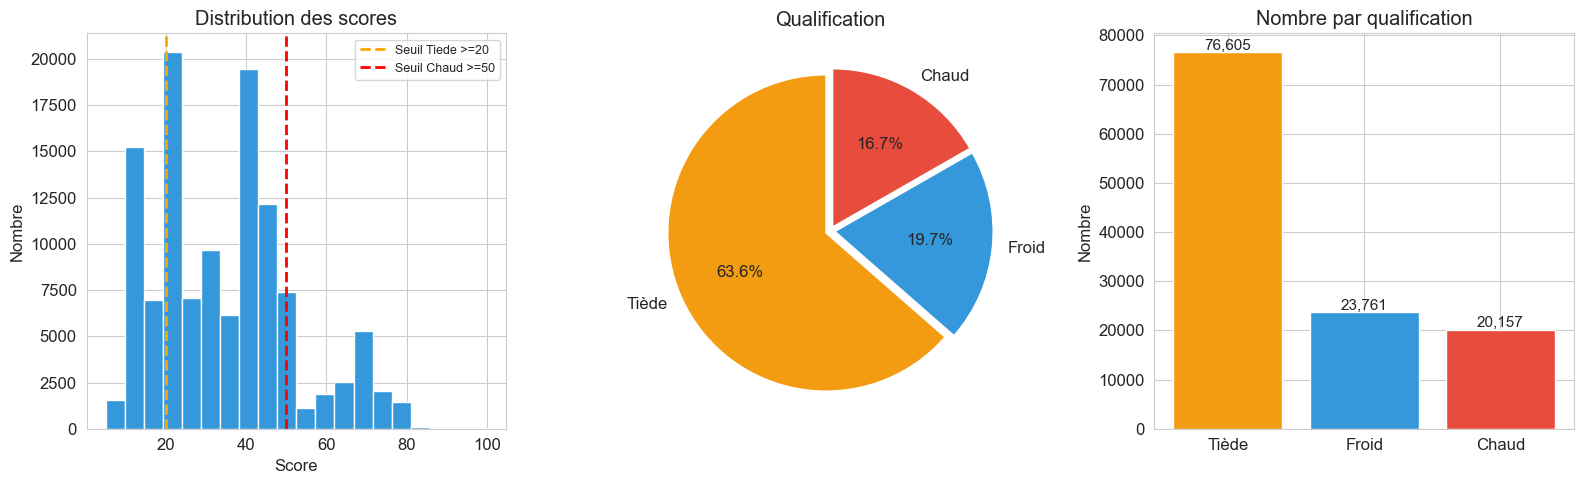

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histogramme des scores
axes[0].hist(df['score'], bins=20, color='#3498db', edgecolor='white')
axes[0].axvline(20, color='orange', ls='--', lw=2, label='Seuil Tiede >=20')
axes[0].axvline(50, color='red', ls='--', lw=2, label='Seuil Chaud >=50')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Nombre')
axes[0].set_title('Distribution des scores')
axes[0].legend(fontsize=9)

# Qualification - Pie
qual_counts = df['qualification'].value_counts()
qual_colors = {'Chaud': '#e74c3c', 'Tiède': '#f39c12', 'Froid': '#3498db'}
wedges, texts, autotexts = axes[1].pie(
    qual_counts.values, labels=qual_counts.index, autopct='%1.1f%%',
    colors=[qual_colors.get(q, '#999') for q in qual_counts.index],
    startangle=90, explode=[0.03]*len(qual_counts)
)
for at in autotexts:
    at.set_fontsize(12)
axes[1].set_title('Qualification')

# Qualification - Bar
bars = axes[2].bar(qual_counts.index, qual_counts.values, color=[qual_colors.get(q, '#999') for q in qual_counts.index], edgecolor='white')
for b in bars:
    axes[2].text(b.get_x()+b.get_width()/2, b.get_height()+500, f"{int(b.get_height()):,}", ha='center', fontsize=11)
axes[2].set_ylabel('Nombre')
axes[2].set_title('Nombre par qualification')

plt.tight_layout()
plt.show()

## 6. Qualification × Type

In [42]:
ct_type = pd.crosstab(df['type'], df['qualification'])
ct_type['Total'] = ct_type.sum(axis=1)
ct_type

qualification,Chaud,Froid,Tiède,Total
type,,,,
Inconnu,0,7225,273,7498
Privé,9515,0,3914,13429
Public,10642,16536,72418,99596


In [43]:
ct_type_pct = ct_type.div(ct_type['Total'], axis=0).drop(columns='Total') * 100
ct_type_pct

qualification,Chaud,Froid,Tiède
type,,,
Inconnu,0.000000,96.359029,3.640971
Privé,70.854122,0.000000,29.145878
Public,10.685168,16.603076,72.711755


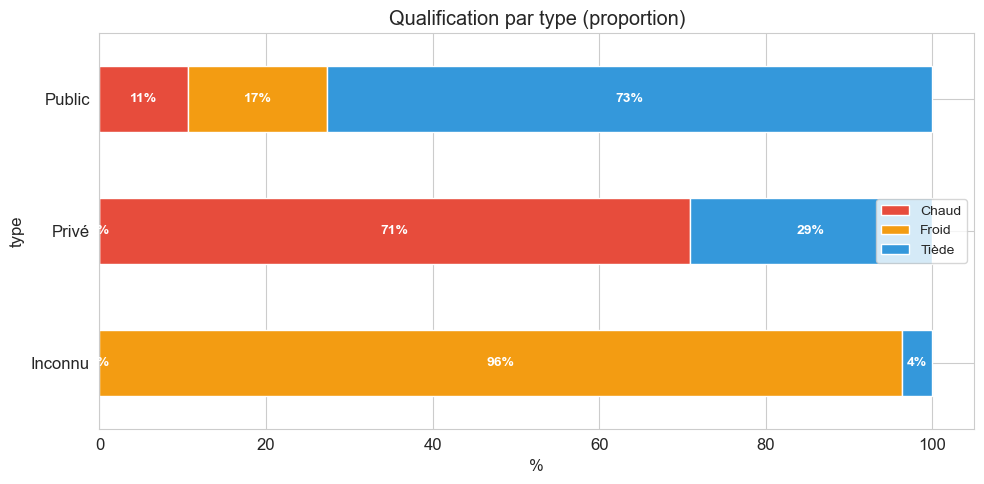

In [44]:
fig, ax = plt.subplots(figsize=(10, 5))
ct_type_pct.plot(kind='barh', stacked=True, ax=ax, color=['#e74c3c', '#f39c12', '#3498db'], edgecolor='white')
for c in ax.containers:
    ax.bar_label(c, label_type='center', fmt='%.0f%%', fontsize=10, color='white', weight='bold')
ax.set_xlabel('%')
ax.set_title('Qualification par type (proportion)')
ax.legend(loc='center right', fontsize=10)
plt.tight_layout()
plt.show()

## 7. Score moyen par type

In [45]:
score_type = df.groupby('type')['score'].agg(['mean', 'median', 'min', 'max', 'count']).round(1)
score_type

,mean,median,min,max,count
type,,,,,
Inconnu,15.6,17.0,5,40,7498
Privé,55.9,52.0,20,100,13429
Public,32.8,32.0,10,95,99596


C:\Users\dheke\AppData\Local\Temp\ipykernel_8792\1337826782.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='type', y='score', palette=[colors.get(t, '#999') for t in df['type'].unique()], ax=ax)


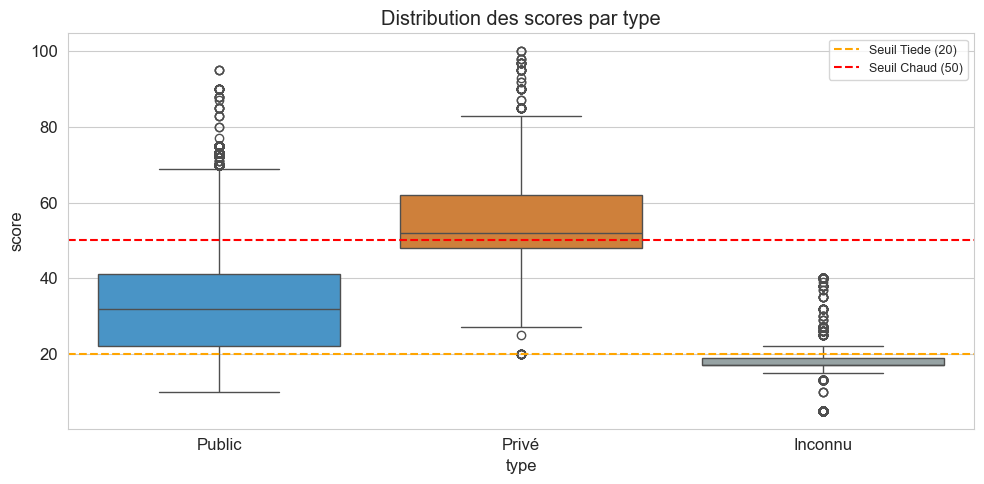

In [46]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='type', y='score', palette=[colors.get(t, '#999') for t in df['type'].unique()], ax=ax)
ax.axhline(20, color='orange', ls='--', lw=1.5, label='Seuil Tiede (20)')
ax.axhline(50, color='red', ls='--', lw=1.5, label='Seuil Chaud (50)')
ax.set_title('Distribution des scores par type')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 8. Qualification × Pays (Top 10 pays)

In [47]:
top10_pays = df['pays'].value_counts().head(10).index
ct_pays = pd.crosstab(df[df['pays'].isin(top10_pays)]['pays'], df[df['pays'].isin(top10_pays)]['qualification'])
ct_pays_pct = ct_pays.div(ct_pays.sum(axis=1), axis=0) * 100
ct_pays_pct

qualification,Chaud,Froid,Tiède
pays,,,
Croatie,2.612956,1.252041,96.135003
Danemark,0.647821,12.426384,86.925795
France,36.816279,0.148562,63.035160
Hongrie,0.887762,58.275206,40.837032
Italie,1.986932,54.713962,43.299107
Norvege,3.727129,28.235826,68.037045
Portugal,0.862610,74.874529,24.262861
Roumanie,1.169231,70.338462,28.492308
Royaume-Uni,7.706483,4.217268,88.076249


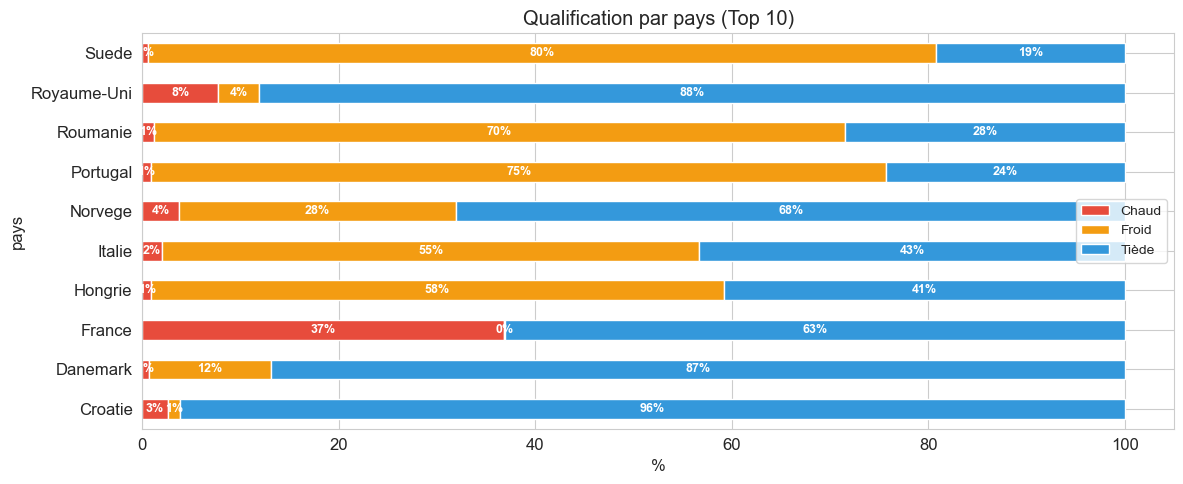

In [48]:
fig, ax = plt.subplots(figsize=(12, 5))
ct_pays_pct.plot(kind='barh', stacked=True, ax=ax, color=['#e74c3c', '#f39c12', '#3498db'], edgecolor='white')
for c in ax.containers:
    ax.bar_label(c, label_type='center', fmt='%.0f%%', fontsize=9, color='white', weight='bold')
ax.set_xlabel('%')
ax.set_title('Qualification par pays (Top 10)')
ax.legend(loc='center right', fontsize=10)
plt.tight_layout()
plt.show()

## 9. Taux de remplissage des champs par qualification

In [49]:
def remplissage(group):
    n = len(group)
    return pd.Series({
        'site_web': (group['site_web'] != '').sum() / n * 100,
        'email': (group['email'] != '').sum() / n * 100,
        'telephone': (group['telephone'] != '').sum() / n * 100,
        'effectif': n
    })

remp = df.groupby('qualification').apply(remplissage).round(1)
remp

C:\Users\dheke\AppData\Local\Temp\ipykernel_8792\2118896180.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  remp = df.groupby('qualification').apply(remplissage).round(1)


,site_web,email,telephone,effectif
qualification,,,,
Chaud,69.7,87.0,89.3,20157.0
Froid,23.6,0.1,2.9,23761.0
Tiède,57.1,43.4,52.3,76605.0


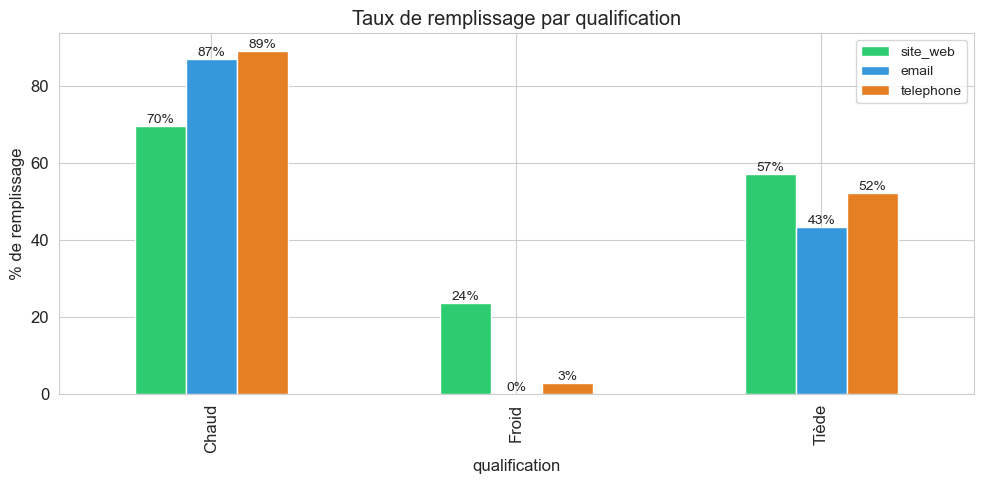

In [50]:
fig, ax = plt.subplots(figsize=(10, 5))
remp[['site_web', 'email', 'telephone']].plot(kind='bar', ax=ax, edgecolor='white', color=['#2ecc71', '#3498db', '#e67e22'])
for c in ax.containers:
    ax.bar_label(c, fmt='%.0f%%', fontsize=10)
ax.set_ylabel('% de remplissage')
ax.set_title('Taux de remplissage par qualification')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 10. Sources des données

In [51]:
src_counts = df['source'].value_counts()
src_counts

source
api_api_osm_eu                    38855
annuaire_france                   36860
api_api_wikidata_eu               35538
api_api_france                     7566
annuaire_tunisie                   1185
web_recherche                       301
annuaire_swiss_private_schools      162
annuaire_enseignement_prive          56
Name: count, dtype: int64

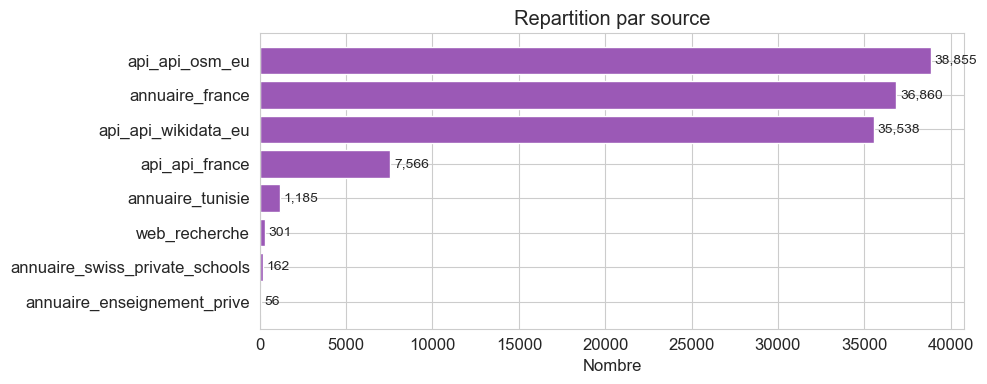

In [52]:
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(src_counts.index, src_counts.values, color='#9b59b6', edgecolor='white')
for b, v in zip(bars, src_counts.values):
    ax.text(b.get_width()+200, b.get_y()+b.get_height()/2, f'{v:,}', va='center', fontsize=10)
ax.set_xlabel('Nombre')
ax.set_title('Repartition par source')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 11. Focus : Inconnus restants (à améliorer)

In [53]:
unk = df[df['type'] == 'Inconnu']
print(f"Inconnus restants : {len(unk)}")
print(f"  dont avec site web  : {(unk['site_web']!='').sum()}")
print(f"  dont avec email     : {(unk['email']!='').sum()}")
print(f"  dont avec telephone : {(unk['telephone']!='').sum()}")
print(f"  Q-codes (Wikidata)  : {unk['nom'].str.match(r'^Q\d+').sum()}")

Inconnus restants : 7498
  dont avec site web  : 5851
  dont avec email     : 156
  dont avec telephone : 300
  Q-codes (Wikidata)  : 4607


In [28]:
unk_qual = unk['qualification'].value_counts()
unk_qual

qualification
Tiède    6239
Froid    2172
Chaud     300
Name: count, dtype: int64

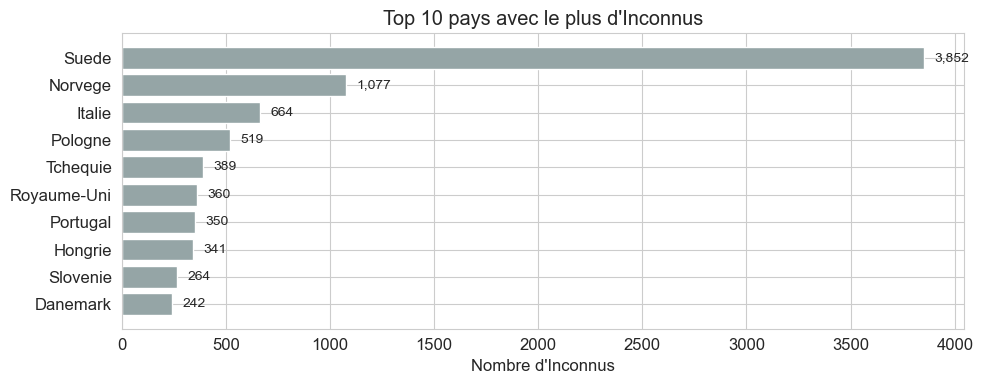

In [27]:
unk_pays = unk['pays'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(range(len(unk_pays)), unk_pays.values, color='#95a5a6', edgecolor='white')
ax.set_yticks(range(len(unk_pays)))
ax.set_yticklabels(unk_pays.index)
ax.invert_yaxis()
for b, v in zip(bars, unk_pays.values):
    ax.text(b.get_width()+50, b.get_y()+b.get_height()/2, f'{v:,}', va='center', fontsize=10)
ax.set_xlabel('Nombre d\'Inconnus')
ax.set_title('Top 10 pays avec le plus d\'Inconnus')
plt.tight_layout()
plt.show()

## 12. Comparaison avant / après nettoyage

In [29]:
before = len(bc)
after = len(df)

comp = pd.DataFrame({
    'Metrique': ['Total prospects', 'Chaud', 'Tiède', 'Froid', 'Supprimes'],
    'Avant clean': [before,
        len(bc[bc['qualification']=='Chaud']),
        len(bc[bc['qualification']=='Tiède']),
        len(bc[bc['qualification']=='Froid']),
        0],
    'Apres clean': [after,
        len(df[df['qualification']=='Chaud']),
        len(df[df['qualification']=='Tiède']),
        len(df[df['qualification']=='Froid']),
        before-after]
})
comp

,Metrique,Avant clean,Apres clean
0,Total prospects,121011,120523
1,Chaud,57223,52802
2,Tiède,43256,48057
3,Froid,20532,19664
4,Supprimes,0,488


## 13. Exemples de prospects Chauds (clients prioritaires)

In [30]:
chaud = df[df['qualification'] == 'Chaud'].copy()
print(f"Total Chaud : {len(chaud)}")
chaud[['nom', 'type', 'pays', 'score', 'site_web', 'email', 'telephone']].head(15)

Total Chaud : 52802


,nom,type,pays,score,site_web,email,telephone
0,Collège Jean Rous,Public,France,75,https://jean-rous.mon-ent-occitanie.fr,ce.0660866h@ac-montpellier.fr,04 68 80 18 70
1,Collège Saint-Philippe Néri,Privé,France,90,http://www.saint-philippe-neri.fr,ce.0060823m@ac-nice.fr,04 97 21 70 50
2,LP René Cassin,Public,France,75,http://lyc-rene-cassin.ac-paris.fr,ce.0750588g@ac-paris.fr,01 42 88 33 66
3,Collège Jean Moulin,Public,France,75,https://webetab.ac-bordeaux.fr/college-jean-mo...,ce.0240047w@ac-bordeaux.fr,05 53 02 08 20
4,Lycée Frédéric Mistral,Public,France,75,https://frederic-mistral-nimes.mon-ent-occitan...,ce.0300058a@ac-montpellier.fr,04 66 04 72 72
5,Lycée polyvalent Irène et Frédéric Joliot-Curie,Public,France,75,https://joliot-curie.mon-ent-occitanie.fr,ce.0340076y@ac-montpellier.fr,04 67 18 66 66
6,Lycée professionnel agricole Honoré de Balzac,Public,France,75,http://www.hdebalzac.fr,lpa.castelnau-le-lez@educagri.fr,04 99 58 36 58
7,Collège privé Saint-Joseph,Privé,France,90,http://stjo-secondigny.fr,ce.0790074b@ac-poitiers.fr,05 49 63 71 02
8,Lycée polyvalent Denis Diderot,Public,France,75,http://www.lyc-diderot.ac-aix-marseille.fr,ce.0130050j@ac-aix-marseille.fr,04 91 10 07 00
9,Lycée Marc Bloch,Public,France,75,https://marc-bloch.lycee.ac-normandie.fr,ce.0271582y@ac-normandie.fr,02 32 59 50 75


## 14. Exemples de prospects Froids (à enrichir)

In [31]:
froid = df[df['qualification'] == 'Froid'].copy()
print(f"Total Froid : {len(froid)}")
froid[['nom', 'type', 'pays', 'score', 'site_web', 'email']].head(15)

Total Froid : 19664


,nom,type,pays,score,site_web,email
73760,Escola Básica de Santo Isidoro,Public,Portugal,15,,
73761,Escola Profissional de Música de Espinho,Public,Portugal,15,,
73762,Escola do Ensino Básico do 2° e 3° Ciclo de Me...,Public,Portugal,15,,
73763,Escola Secundária de São João da Talha,Public,Portugal,15,,
73764,Escola Básica da Quinta da Condessa,Public,Portugal,15,,
73765,Escola Básica e Jardim de Infância do Bacêlo,Public,Portugal,15,,
73766,Escola das Pedreiras (Antiga),Public,Portugal,15,,
73767,Escola Primária de Hombres,Public,Portugal,15,,
73768,Escola Primária do Porto Moniz,Public,Portugal,15,,
73769,Escola Primária,Public,Portugal,15,,


---
**Rapport généré le 10/06/2026 — Pipeline agent EdTech TUT'TOP**